 Imports & Configuration

In [10]:
import warnings
warnings.filterwarnings('ignore')

# Core
import numpy as np
import pandas as pd
from IPython.display import display

# Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Patch

# Stats
from scipy import stats
from scipy.stats import chi2_contingency, mannwhitneyu, shapiro, ks_2samp


plt.rcParams.update({
    'figure.dpi':        150,
    'figure.facecolor':  '#ffffff',   
    'axes.facecolor':    '#f7f9fc',   
    'axes.edgecolor':    '#cccccc',   
    'axes.labelcolor':   '#222222',   
    'axes.titlecolor':   '#111111',   
    'axes.titlesize':    14,
    'axes.labelsize':    11,
    'axes.spines.top':   False,       
    'axes.spines.right': False,       
    'xtick.color':       '#444444',
    'ytick.color':       '#444444',
    'xtick.labelsize':   10,
    'ytick.labelsize':   10,
    'text.color':        '#222222',
    'grid.color':        '#e0e0e0',
    'grid.linestyle':    '--',
    'grid.alpha':        0.7,
    'legend.facecolor':  '#ffffff',
    'legend.edgecolor':  '#cccccc',
    'legend.fontsize':   9,
    'font.family':       'DejaVu Sans',
})

# ── Brand colors ─────────────────────────────────────────────
FRAUD_COLOR  = '#e63946'   
LEGIT_COLOR  = '#457b9d'   
ACCENT_COLOR = '#f4a261'   
PALETTE      = [LEGIT_COLOR, FRAUD_COLOR]

In [11]:
import os

def save_plot(fig, filename, output_dir='./outputs/preparation'):
    os.makedirs(output_dir, exist_ok=True)
    filepath = os.path.join(output_dir, filename)
    fig.savefig(filepath, dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
    print(f"Plot saved → {filepath}")

In [12]:
df = pd.read_csv('./data/raw/credit_card_fraud_10k.csv')

 FEATURE ENGINEERING

In [13]:
# ── 1. Log-transform amount ──────────────────────────────────
df['amount_log'] = np.log1p(df['amount'])

# ── 2. Night flag (midnight to 6 AM) ────────────────────────
df['is_night'] = (df['transaction_hour'] < 6).astype(int)

# ── 3. Z-score of amount ────────────────────────────────────
df['amount_zscore'] = (df['amount'] - df['amount'].mean()) / df['amount'].std()

# ── 4. High amount flag (above 75th percentile) ─────────────
q75 = df['amount'].quantile(0.75)
df['high_amount'] = (df['amount'] > q75).astype(int)

# ── 5. Amount quantile bins ─────────────────────────────────
df['amount_bin'] = pd.qcut(df['amount'], q=5,
                            labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'],
                            duplicates='drop')

# ── 6. High velocity flag ───────────────────────────────────
df['high_velocity'] = (df['velocity_last_24h'] > df['velocity_last_24h'].median()).astype(int)

# ── 7. Composite risk score ─────────────────────────────────
df['risk_score'] = df['foreign_transaction'] + df['location_mismatch'] + df['high_velocity']

In [14]:
new_features = ['amount_log', 'is_night', 'amount_zscore',
                'high_amount', 'amount_bin', 'high_velocity', 'risk_score']

print(" New Features Created:")
print(f"{'Feature':<20} {'dtype':<12} {'Non-null':<10} Sample Values")
print("-" * 60)
for feat in new_features:
    sample = df[feat].dropna().iloc[:3].tolist()
    print(f"{feat:<20} {str(df[feat].dtype):<12} {df[feat].notna().sum():<10} {sample}")

print(f"\n Updated DataFrame Shape: {df.shape}")

 New Features Created:
Feature              dtype        Non-null   Sample Values
------------------------------------------------------------
amount_log           float64      10000      [4.448165437177926, 6.296777773265705, 5.472312689595516]
is_night             int32        10000      [0, 1, 0]
amount_zscore        float64      10000      [-0.5215712091278738, 2.0860040667630297, 0.34813368337108397]
high_amount          int32        10000      [0, 1, 0]
amount_bin           category     10000      ['Low', 'Very High', 'High']
high_velocity        int32        10000      [1, 0, 0]
risk_score           int64        10000      [1, 1, 0]

 Updated DataFrame Shape: (10000, 17)


Correlation Heatmap : 
A correlation matrix tells us how linearly related each pair of features is, ranging from −1 (perfect inverse) to +1 (perfect positive).

In [15]:
# Select numeric columns for correlation (drop amount_bin which is categorical)
numeric_cols = ['amount', 'amount_log', 'transaction_hour', 'is_night',
                'amount_zscore', 'high_amount', 'high_velocity',
                'risk_score', 'foreign_transaction', 'location_mismatch',
                'device_trust_score', 'velocity_last_24h', 'cardholder_age', 'is_fraud']

corr_matrix = df[numeric_cols].corr()


Plot saved → ./outputs/preparation\correlation_heatmap_full.png


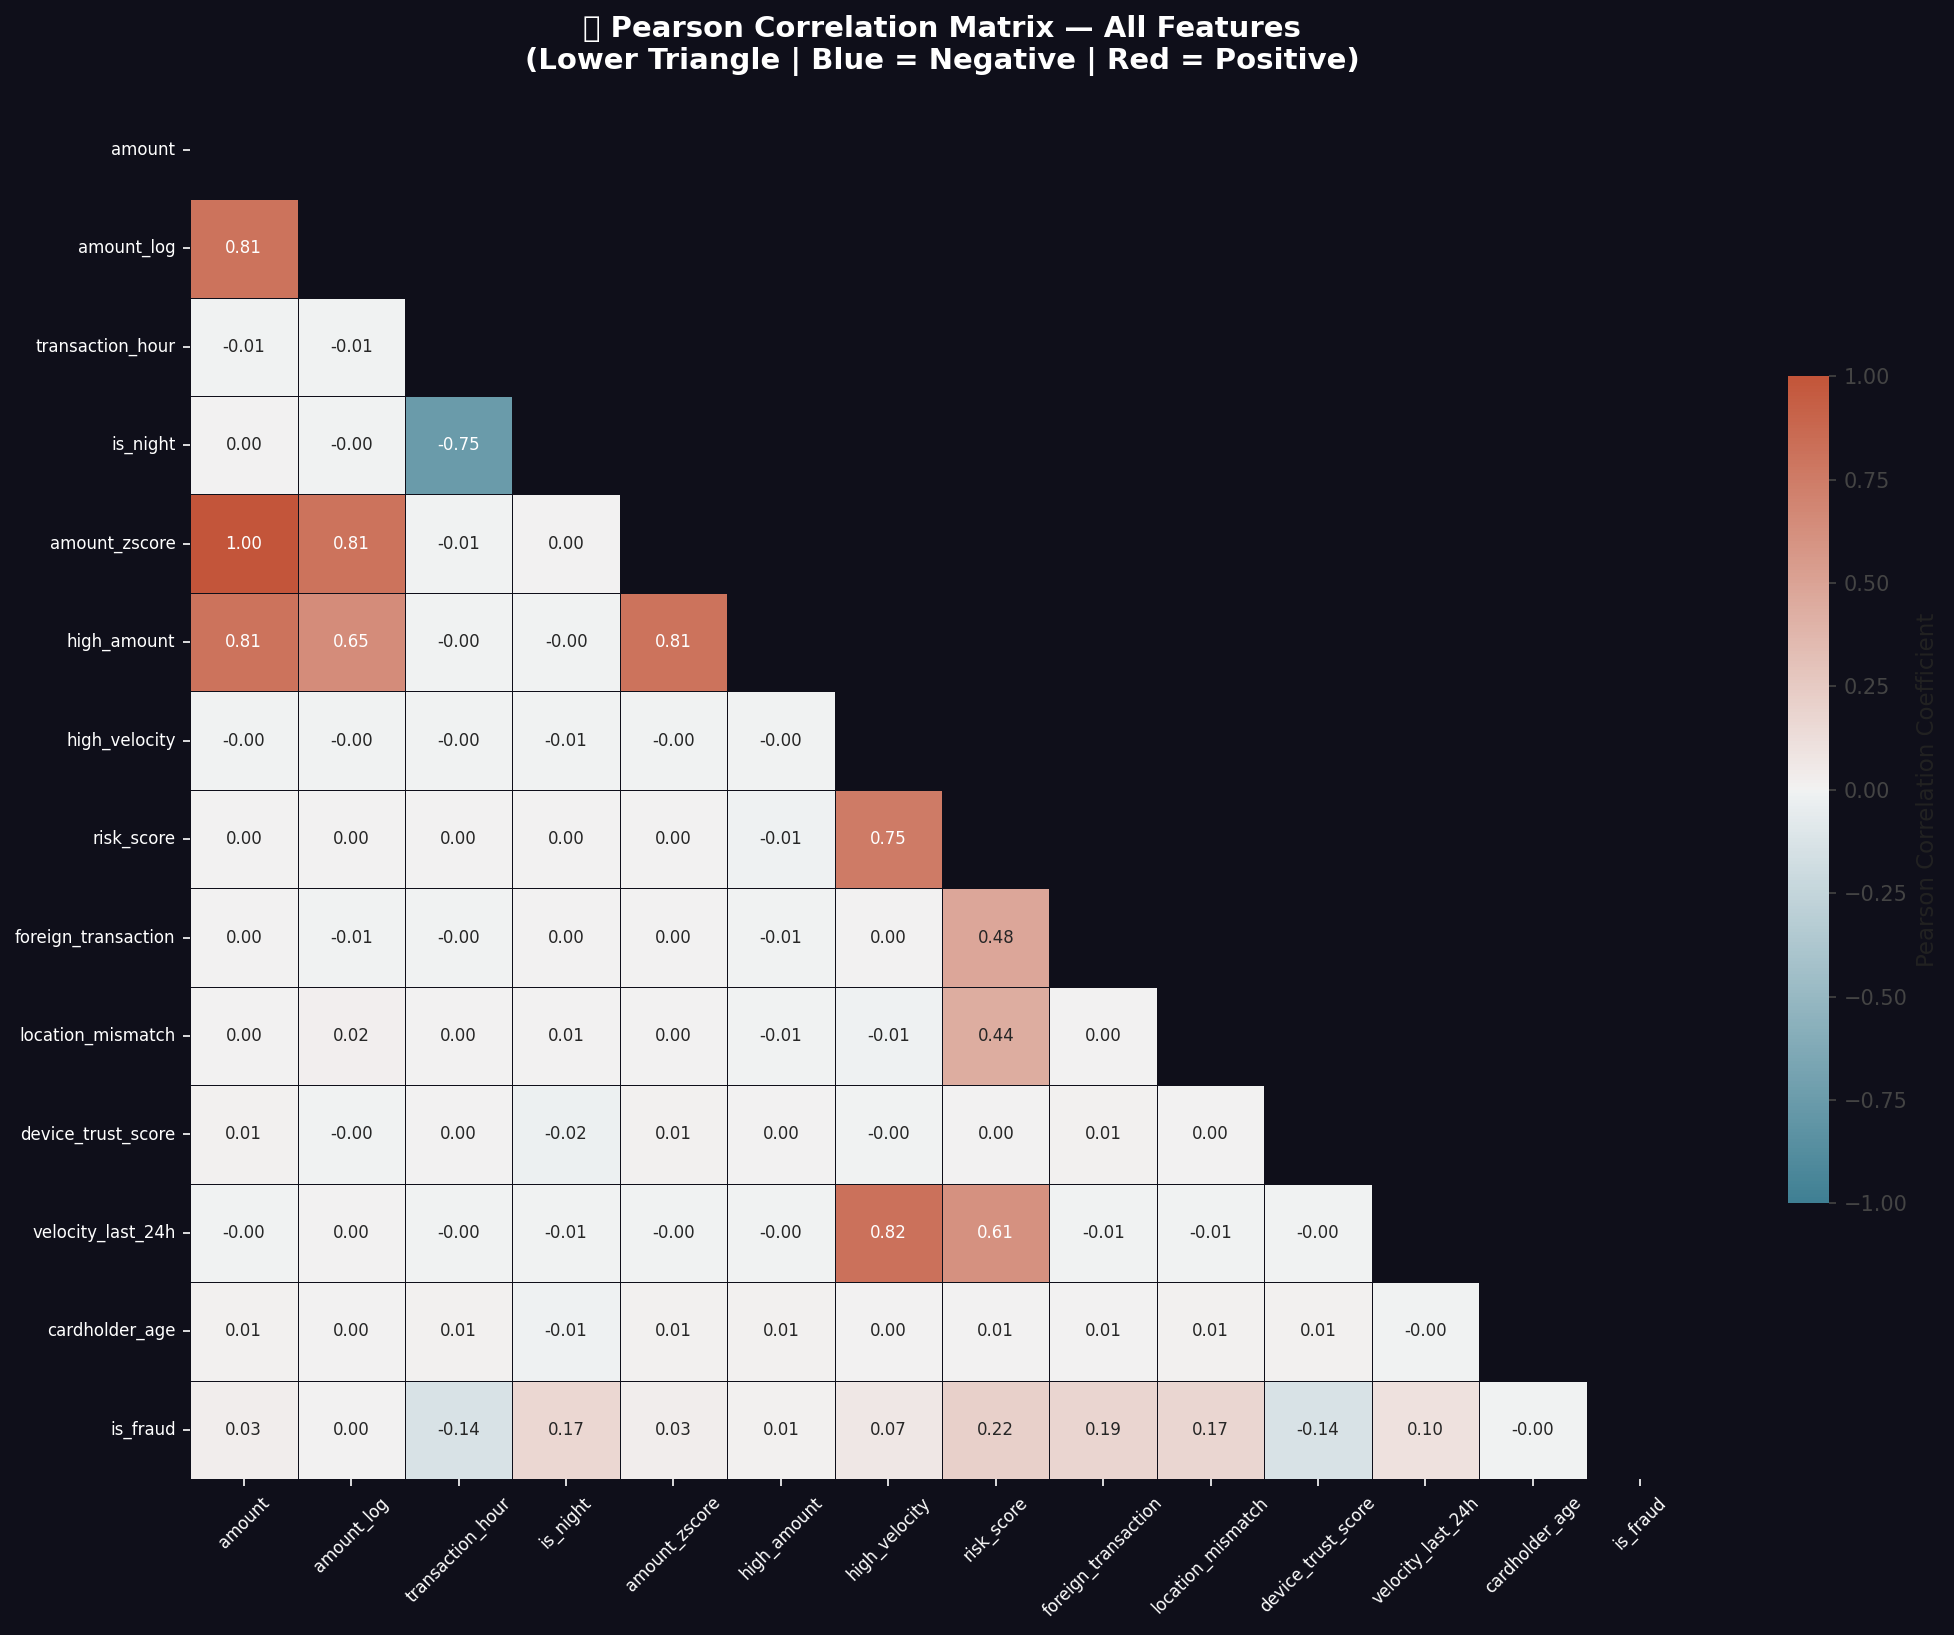

In [16]:
# ── Figure 1: Full Heatmap ───────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 11))
fig.patch.set_facecolor('#0f0f1a')
ax.set_facecolor('#0f0f1a')

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
cmap = sns.diverging_palette(220, 20, as_cmap=True)

sns.heatmap(
    corr_matrix, mask=mask, cmap=cmap, center=0,
    vmin=-1, vmax=1, annot=True, fmt='.2f', linewidths=0.3,
    linecolor='#0f0f1a', ax=ax, annot_kws={'size': 8},
    cbar_kws={'shrink': 0.6, 'label': 'Pearson Correlation Coefficient'}
)
ax.set_title('📊 Pearson Correlation Matrix — All Features\n'
             '(Lower Triangle | Blue = Negative | Red = Positive)',
             fontsize=14, fontweight='bold', color='white', pad=15)
ax.tick_params(axis='x', rotation=45, labelsize=8, colors='white')
ax.tick_params(axis='y', rotation=0,  labelsize=8, colors='white')
plt.tight_layout()
save_plot(fig, 'correlation_heatmap_full.png')
plt.show()

Plot saved → ./outputs/preparation\correlation_with_fraud.png


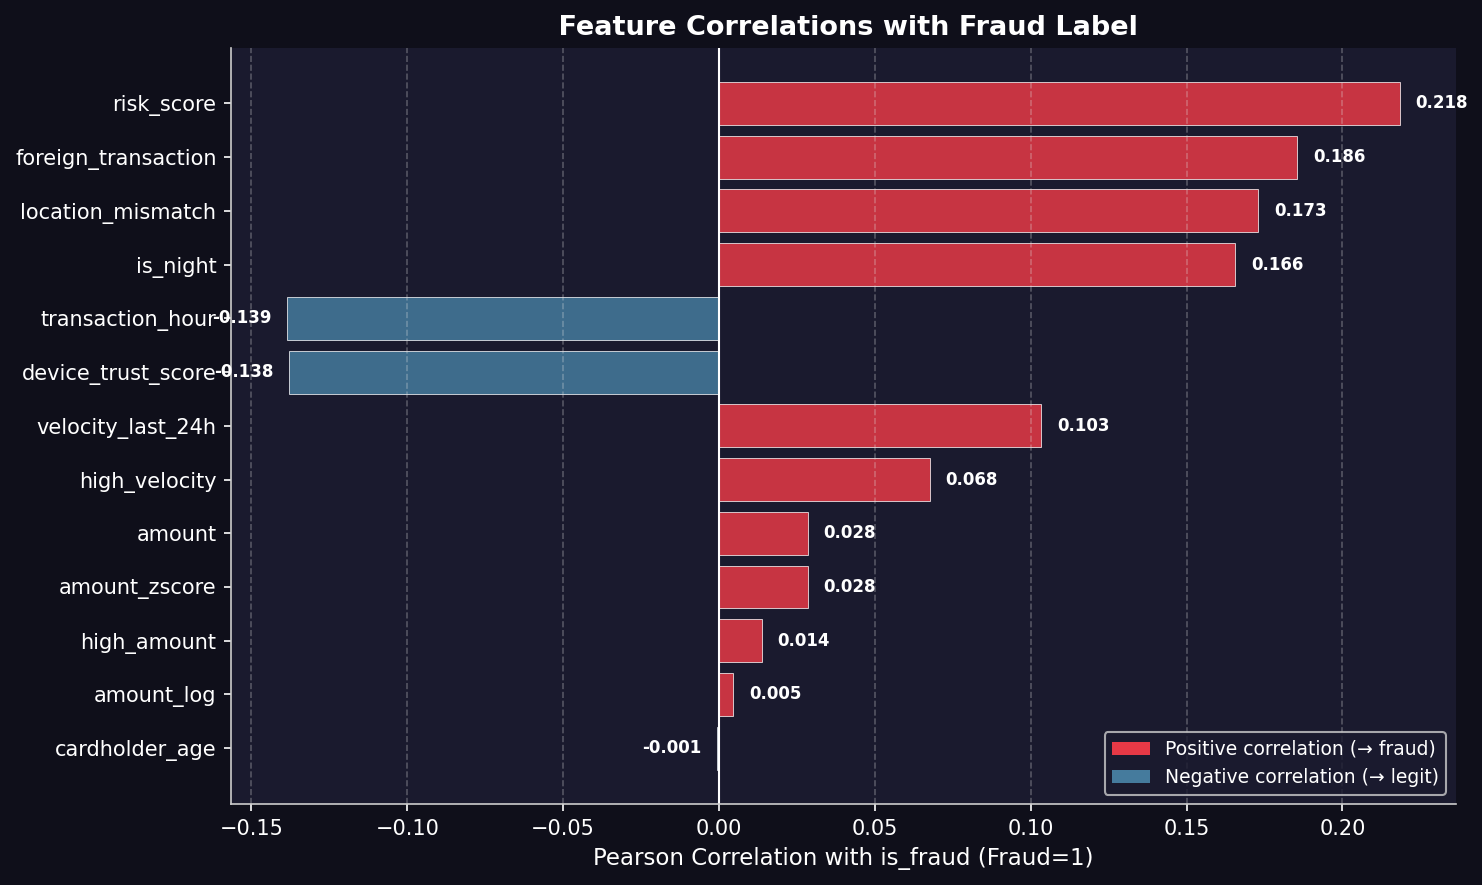

Feature correlations with fraud (ranked):
risk_score             0.218450
foreign_transaction    0.185597
location_mismatch      0.173009
is_night               0.165626
transaction_hour      -0.138665
device_trust_score    -0.137913
velocity_last_24h      0.103413
high_velocity          0.067639
amount                 0.028404
amount_zscore          0.028404
high_amount            0.013729
amount_log             0.004608
cardholder_age        -0.000590


In [17]:
# ── Figure 2: Top correlations with is_fraud ─────────────────
class_corr = corr_matrix['is_fraud'].drop('is_fraud').sort_values(key=abs, ascending=False)
top_n = class_corr.head(13)   # all 13 remaining features

fig2, ax2 = plt.subplots(figsize=(10, 6))
fig2.patch.set_facecolor('#0f0f1a')
ax2.set_facecolor('#1a1a2e')

colors = [FRAUD_COLOR if v > 0 else LEGIT_COLOR for v in top_n.values]
bars = ax2.barh(top_n.index[::-1], top_n.values[::-1],
                color=colors[::-1], alpha=0.85,
                edgecolor='white', linewidth=0.4)
ax2.axvline(0, color='white', linewidth=1)
for bar, val in zip(bars, top_n.values[::-1]):
    ax2.text(val + (0.005 if val > 0 else -0.005),
             bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center',
             ha='left' if val > 0 else 'right',
             fontsize=8, color='white', fontweight='bold')
ax2.set_xlabel('Pearson Correlation with is_fraud (Fraud=1)', color='white')
ax2.set_title(' Feature Correlations with Fraud Label',
              fontweight='bold', fontsize=13, color='white')
ax2.tick_params(colors='white')
legend_elements = [Patch(facecolor=FRAUD_COLOR, label='Positive correlation (→ fraud)'),
                   Patch(facecolor=LEGIT_COLOR,  label='Negative correlation (→ legit)')]
ax2.legend(handles=legend_elements, loc='lower right',
           facecolor='#1a1a2e', labelcolor='white')
ax2.grid(axis='x', alpha=0.3)
plt.tight_layout()
save_plot(fig2, 'correlation_with_fraud.png')
plt.show()

print("Feature correlations with fraud (ranked):")
print(class_corr.to_string())

Encode categorical features

In [19]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

In [20]:
df_model = df.copy()
le = LabelEncoder()
df_model['merchant_category_enc'] = le.fit_transform(df_model['merchant_category'])
df_model['amount_bin_enc']        = le.fit_transform(df_model['amount_bin'].astype(str))

Feature set

In [22]:
feature_cols = [
    'amount', 'amount_log', 'transaction_hour', 'is_night',
    'foreign_transaction', 'location_mismatch', 'device_trust_score',
    'velocity_last_24h', 'cardholder_age', 'high_amount', 'high_velocity',
    'risk_score', 'merchant_category_enc', 'amount_bin_enc'
]

X = df_model[feature_cols]
y = df_model['is_fraud']

Train/Test Split

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

Scale features

In [25]:
scaler  = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(" Preprocessing Complete")
print(f"   Train size : {X_train.shape[0]:,} ({y_train.mean()*100:.2f}% fraud)")
print(f"   Test size  : {X_test.shape[0]:,} ({y_test.mean()*100:.2f}% fraud)")
print(f"   Features   : {len(feature_cols)}")

 Preprocessing Complete
   Train size : 8,000 (1.51% fraud)
   Test size  : 2,000 (1.50% fraud)
   Features   : 14


SMOTE: Handling Class Imbalance

In [26]:
from imblearn.over_sampling import SMOTE
from collections import Counter

print("  Class distribution BEFORE SMOTE:")
print(f"   Legitimate : {Counter(y_train)[0]:,}")
print(f"   Fraud      : {Counter(y_train)[1]:,}")
print(f"   Ratio      : {Counter(y_train)[0]/Counter(y_train)[1]:.1f}:1")

smote = SMOTE(random_state=42, k_neighbors=5)
X_train_sm, y_train_sm = smote.fit_resample(X_train_scaled, y_train)

print("\n Class distribution AFTER SMOTE:")
print(f"   Legitimate : {Counter(y_train_sm)[0]:,}")
print(f"   Fraud      : {Counter(y_train_sm)[1]:,}")
print(f"   Ratio      : {Counter(y_train_sm)[0]/Counter(y_train_sm)[1]:.1f}:1")

  Class distribution BEFORE SMOTE:
   Legitimate : 7,879
   Fraud      : 121
   Ratio      : 65.1:1

 Class distribution AFTER SMOTE:
   Legitimate : 7,879
   Fraud      : 7,879
   Ratio      : 1.0:1


Visualize SMOTE effect

Plot saved → ./outputs/preparation\smote_effect.png


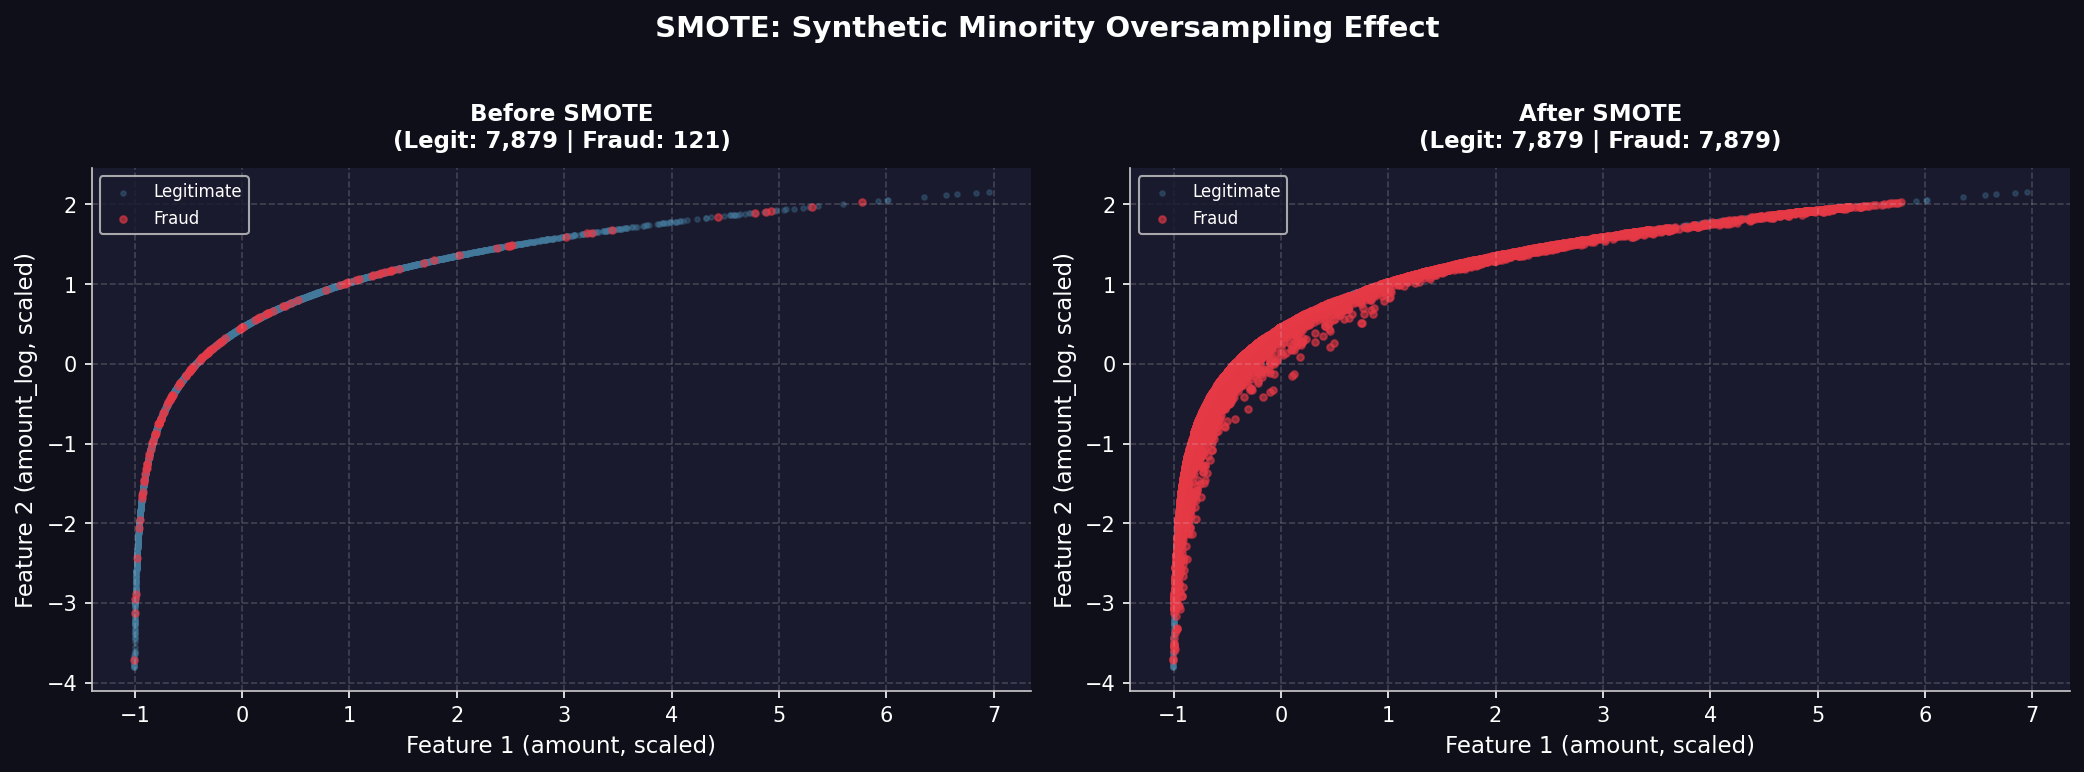

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0f0f1a')

for ax, (X_plot, y_plot, title) in zip(axes, [
    (X_train_scaled, y_train,    'Before SMOTE'),
    (X_train_sm,     y_train_sm, 'After SMOTE')
]):
    ax.set_facecolor('#1a1a2e')
    # Plot first 2 features as proxy
    ax.scatter(X_plot[y_plot == 0, 0], X_plot[y_plot == 0, 1],
               color=LEGIT_COLOR, alpha=0.3, s=5, label='Legitimate')
    ax.scatter(X_plot[y_plot == 1, 0], X_plot[y_plot == 1, 1],
               color=FRAUD_COLOR, alpha=0.6, s=10, label='Fraud')
    ax.set_title(f'{title}\n(Legit: {Counter(y_plot)[0]:,} | Fraud: {Counter(y_plot)[1]:,})',
                 fontweight='bold', fontsize=11, color='white', pad=10)
    ax.set_xlabel('Feature 1 (amount, scaled)', color='white')
    ax.set_ylabel('Feature 2 (amount_log, scaled)', color='white')
    ax.legend(fontsize=8, facecolor='#1a1a2e', labelcolor='white')
    ax.tick_params(colors='white')
    ax.grid(alpha=0.2)

plt.suptitle(' SMOTE: Synthetic Minority Oversampling Effect',
             fontsize=14, fontweight='bold', color='white', y=1.02)
plt.tight_layout()
save_plot(fig, 'smote_effect.png')
plt.show()

Save to data/processed

In [28]:
output_dir = 'data/processed'
os.makedirs(output_dir, exist_ok=True)

pd.DataFrame(X_train_sm,    columns=feature_cols).to_csv(f'{output_dir}/X_train.csv', index=False)
pd.DataFrame(X_test_scaled, columns=feature_cols).to_csv(f'{output_dir}/X_test.csv',  index=False)
pd.Series(y_train_sm, name='is_fraud').to_csv(f'{output_dir}/y_train.csv', index=False)
pd.Series(y_test,     name='is_fraud').to_csv(f'{output_dir}/y_test.csv',  index=False)

print(f"\nFiles saved in {output_dir}/")
print(f"   X_train.csv → {X_train_sm.shape}")
print(f"   X_test.csv  → {X_test_scaled.shape}")
print(f"   y_train.csv → {len(y_train_sm):,} rows")
print(f"   y_test.csv  → {len(y_test):,} rows")


Files saved in data/processed/
   X_train.csv → (15758, 14)
   X_test.csv  → (2000, 14)
   y_train.csv → 15,758 rows
   y_test.csv  → 2,000 rows
